# Motional dephasing rateの2・3・4次近似

motional dephasingのみを有効にし、error generatorのrate応答を

$$
\Delta K(m,\bar n)=K(m,\bar n)-K(0,\bar n)
=\sum_{p=1}^{d}m^p K^{(p)}(\bar n),\qquad d=2,3,4
$$

で近似する。既存のQPT点で係数を学習し、学習に使っていないrateの完全QPTで次数と有効範囲を検証する。

計算・展開・保存・描画の関数はすべて `motional_dephasing_polynomial_analysis.py` に置き、このnotebookでは変数設定と関数呼び出しのみを行う。

In [1]:
from pathlib import Path
import importlib
import os

# QPT worker内のBLAS/OpenMP多重並列を避ける。
for name in (
    'OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS',
    'VECLIB_MAXIMUM_THREADS', 'NUMEXPR_NUM_THREADS',
):
    os.environ[name] = '1'
os.environ.setdefault('MPLCONFIGDIR', '/tmp/ms_gate_mpl')

import pandas as pd
from IPython.display import Image, display

import motional_dephasing_polynomial_analysis as mdpa
mdpa = importlib.reload(mdpa)

## 1. 計算条件

`TRAIN_MULTIPLIERS` は多項式係数の学習点、`VALIDATION_MULTIPLIERS` は汎化誤差を測る独立QPT点である。四次近似は定数項をゼロに固定するため、ゼロ以外の学習点が少なくとも4点必要になる。

In [ ]:
TRAINING_CACHE = Path('results/error_generator_rate_nbar/top3_pairwise_generator')
OUTPUT_DIR = Path('results/motional_dephasing_polynomial')

NOMINAL_RATE = 18.0  # motional dephasing nominal rate [s^-1]
TRAIN_MULTIPLIERS = (0.0, 0.5, 1.0, 2.0, 4.0)
VALIDATION_MULTIPLIERS = (0.25, 0.75, 1.5, 3.0)
NBAR_VALUES = (0.01, 1.0, 2.0, 3.0, 4.0)
DEGREES = (2, 3, 4)

# 個別に曲線を表示する主要H/S/C/A成分。
KEY_MODES = (
    ('H', 'XX'),
    ('S', 'IX'),
    ('C', 'IX,XI'),
    ('S', 'XX'),
)

WORKERS = min(32, os.cpu_count() or 1)
SHOW_PROGRESS = True
QPT_BATCH_SIZE = 1  # 1温度点ごとに保存し、中断後に再開可能にする。
EXECUTE_QPT = True  # Falseで既存キャッシュの読出しのみ。

## 2. QPT・多項式近似・独立検証

次のセルを実行すると、未計算の独立検証点についてmaster equationとQPTが走る。完了済みのcondition/$\bar n$点はキャッシュから再利用される。

In [ ]:
result = mdpa.analyze_polynomial_orders(
    training_cache=TRAINING_CACHE,
    output_dir=OUTPUT_DIR,
    execute=EXECUTE_QPT,
    nominal_rate=NOMINAL_RATE,
    training_multipliers=TRAIN_MULTIPLIERS,
    validation_multipliers=VALIDATION_MULTIPLIERS,
    nbar_values=NBAR_VALUES,
    degrees=DEGREES,
    key_modes=KEY_MODES,
    parallel_workers=WORKERS,
    show_progress=SHOW_PROGRESS,
    qpt_batch_size=QPT_BATCH_SIZE,
)

## 3. 検証結果

学習に使っていないrateに対する全error generatorの相対Frobenius誤差を表示する。`aggregate_relative_residual` は4つの検証rateをまとめた誤差、`max_point_relative_residual` はその中の最大誤差である。

In [ ]:
matrix_validation = (
    result['metrics']
    .query("dataset == 'independent_validation'")
    .sort_values(['nbar', 'polynomial_degree'])
)
display(matrix_validation)
display(Image(filename=str(result['degree_figure'])))
display(Image(filename=str(result['curve_figure'])))

In [ ]:
coefficient_validation = (
    result['coefficient_metrics']
    .query("dataset == 'independent_validation'")
    .sort_values(['sector', 'mode', 'nbar', 'polynomial_degree'])
)
display(coefficient_validation)

## 4. ゼロrate極限のDyson–Fréchet Taylor係数

前節の係数は有限rate区間への大域的な多項式フィットであり、そのままでは $\Gamma=0$ における微分係数とは主張できない。ここでは物理的に許される正のrateのみを用い、片側ステンシル

$$m_j=jh,\qquad j=1,2,3,4$$

から4次局所多項式を求める。$h,h/2,h/4$ と細分化したときに $K^{(p)}(h)$ が収束するかを調べる。4次フィットで未考慮の先頭項が5次であるなら、$p$ 次係数の期待収束次数は

$$q_p=5-p=(4,3,2,1)$$

となる。係数の相対変化が小さくなり、観測収束次数が正で理論値に近づくことをTaylor係数同定の数値的証拠とする。

In [8]:
TAYLOR_OUTPUT_DIR = OUTPUT_DIR / 'dyson_frechet_taylor'

# h -> h/2 -> h/4 の幾何級数。収束が見えなければ 0.025 を追加する。
TAYLOR_STEP_SIZES = (0.2, 0.1, 0.05)
TAYLOR_STENCIL_MULTIPLES = (1.0, 2.0, 3.0, 4.0)
TAYLOR_TRUNCATION_DEGREES = (2, 3, 4)
TAYLOR_NBAR_VALUES = NBAR_VALUES
TAYLOR_COEFFICIENT_RTOL = 0.05

TAYLOR_WORKERS = WORKERS
TAYLOR_SHOW_PROGRESS = True
TAYLOR_QPT_BATCH_SIZE = 1
TAYLOR_EXECUTE_QPT = True

TAYLOR_RATE_MULTIPLIERS = tuple(sorted({
    round(h * j, 12)
    for h in TAYLOR_STEP_SIZES
    for j in TAYLOR_STENCIL_MULTIPLES
}))
print('Near-zero multipliers:', TAYLOR_RATE_MULTIPLIERS)
print('Physical rates [s^-1]:', tuple(m * NOMINAL_RATE for m in TAYLOR_RATE_MULTIPLIERS))
print('New QPT points:', len(TAYLOR_RATE_MULTIPLIERS) * len(TAYLOR_NBAR_VALUES))

Near-zero multipliers: (0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.6, 0.8)
Physical rates [s^-1]: (0.9, 1.8, 2.6999999999999997, 3.6, 5.3999999999999995, 7.2, 10.799999999999999, 14.4)
New QPT points: 40


### 4.1 ゼロ近傍QPTと収束解析

次のセルがmaster equationを実行する。`TAYLOR_QPT_BATCH_SIZE=1` でcondition/$\bar n$点ごとに保存されるため、中断後は未完了点から再開できる。

In [9]:
# Pythonファイルの更新を反映し、古いmodule cacheの使用を防ぐ。
mdpa = importlib.reload(mdpa)
print('Loaded analysis module:', Path(mdpa.__file__).resolve())
if not hasattr(mdpa, 'analyze_dyson_frechet_taylor_convergence'):
    raise RuntimeError(
        'Taylor convergence function is missing. '
        'Check that the displayed module path is this project directory.'
    )

taylor_result = mdpa.analyze_dyson_frechet_taylor_convergence(
    training_cache=TRAINING_CACHE,
    output_dir=TAYLOR_OUTPUT_DIR,
    execute=TAYLOR_EXECUTE_QPT,
    nominal_rate=NOMINAL_RATE,
    step_sizes=TAYLOR_STEP_SIZES,
    stencil_multiples=TAYLOR_STENCIL_MULTIPLES,
    nbar_values=TAYLOR_NBAR_VALUES,
    truncation_degrees=TAYLOR_TRUNCATION_DEGREES,
    key_modes=KEY_MODES,
    parallel_workers=TAYLOR_WORKERS,
    show_progress=TAYLOR_SHOW_PROGRESS,
    qpt_batch_size=TAYLOR_QPT_BATCH_SIZE,
    coefficient_rtol=TAYLOR_COEFFICIENT_RTOL,
)

Loaded analysis module: /Users/hirainoa/Desktop/量子/project/Moon_shot__高橋PJ/MS_gate_Hirai/motional_dephasing_polynomial_analysis.py
Run near-zero Taylor QPT: motional dephasing m=0.05, nbar=[0.01]


MS gate simulation (16 evolutions / n_bar):   0%|          | 0/16 [00:00<?, ?evolution/s]

Run near-zero Taylor QPT: motional dephasing m=0.05, nbar=[1.0]


MS gate simulation (16 evolutions / n_bar):   0%|          | 0/16 [00:00<?, ?evolution/s]

Run near-zero Taylor QPT: motional dephasing m=0.05, nbar=[2.0]


...

MS gate simulation (16 evolutions / n_bar):   0%|          | 0/16 [00:00<?, ?evolution/s]

Run near-zero Taylor QPT: motional dephasing m=0.8, nbar=[3.0]


MS gate simulation (16 evolutions / n_bar):   0%|          | 0/16 [00:00<?, ?evolution/s]

Run near-zero Taylor QPT: motional dephasing m=0.8, nbar=[4.0]


MS gate simulation (16 evolutions / n_bar):   0%|          | 0/16 [00:00<?, ?evolution/s]

### 4.2 full generator係数の収束

`relative_coefficient_change` は連続する2つのステンシルで求めた $K^{(p)}$ の差を、細い側の係数のFrobenius normで規格化した値である。

,nbar,rate_power,coarse_step_size,fine_step_size,fine_maximum_stencil_multiplier,coefficient_difference_frobenius,fine_coefficient_frobenius,relative_coefficient_change,relative_converged,coefficient_rtol
4,0.01,1,0.1,0.05,0.2,0.000029,0.003320,0.008718,True,0.05
0,0.01,1,0.2,0.10,0.4,0.000017,0.003319,0.005224,True,0.05
5,0.01,2,0.1,0.05,0.2,0.000695,0.000679,1.023209,False,0.05
1,0.01,2,0.2,0.10,0.4,0.000206,0.000178,1.154140,False,0.05
6,0.01,3,0.1,0.05,0.2,0.005443,0.005378,1.012205,False,0.05
2,0.01,3,0.2,0.10,0.4,0.000793,0.000746,1.063661,False,0.05
7,0.01,4,0.1,0.05,0.2,0.013537,0.013459,1.005748,False,0.05
3,0.01,4,0.2,0.10,0.4,0.000973,0.000947,1.027752,False,0.05
12,1.00,1,0.1,0.05,0.2,0.000019,0.008519,0.002228,True,0.05
8,1.00,1,0.2,0.10,0.4,0.000012,0.008519,0.001424,True,0.05


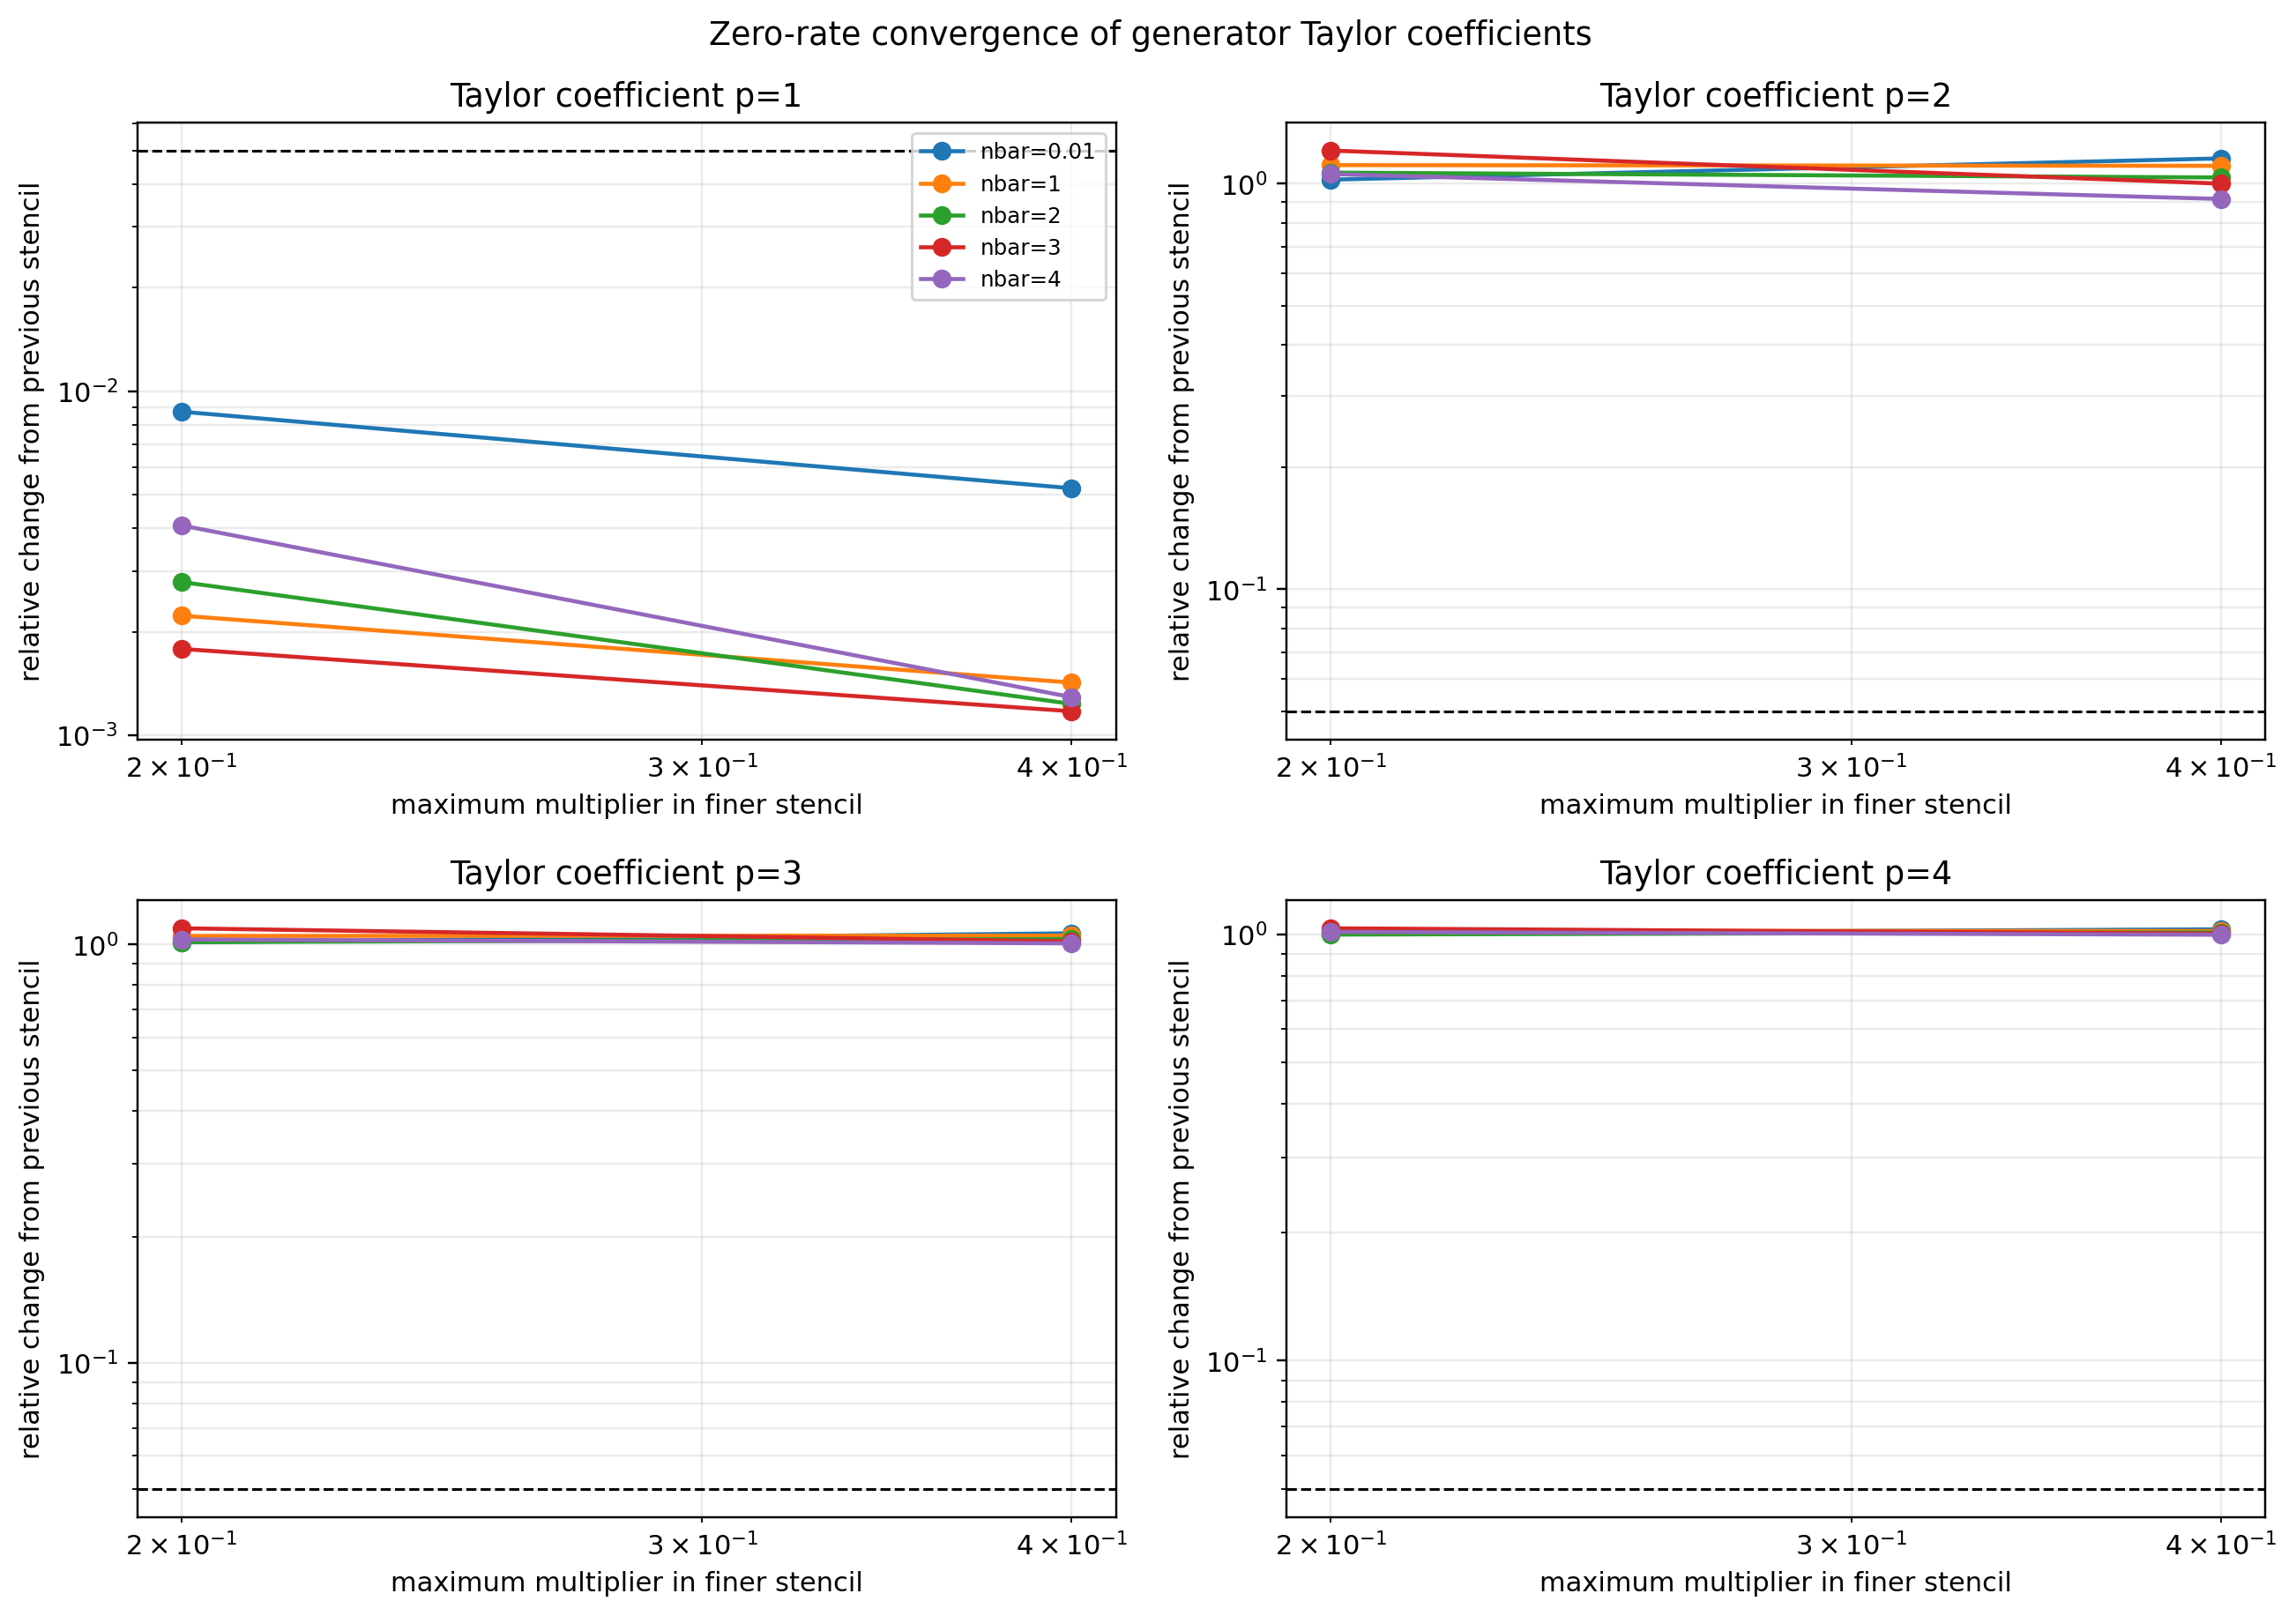

In [10]:
generator_convergence = (
    taylor_result['generator_convergence']
    .sort_values(['nbar', 'rate_power', 'fine_step_size'])
)
display(generator_convergence)
display(Image(filename=str(taylor_result['coefficient_figure'])))

In [11]:
observed_orders = (
    taylor_result['observed_orders']
    .sort_values(['nbar', 'rate_power', 'fine_step_size'])
)
display(observed_orders)

,nbar,rate_power,coarse_step_size,middle_step_size,fine_step_size,coarse_middle_difference_frobenius,middle_fine_difference_frobenius,observed_convergence_order,expected_asymptotic_order,order_difference
0,0.01,1,0.2,0.1,0.05,0.000017,0.000029,-0.739153,4,-4.739153
1,0.01,2,0.2,0.1,0.05,0.000206,0.000695,-1.756625,3,-4.756625
2,0.01,3,0.2,0.1,0.05,0.000793,0.005443,-2.778762,2,-4.778762
3,0.01,4,0.2,0.1,0.05,0.000973,0.013537,-3.798046,1,-4.798046
4,1.00,1,0.2,0.1,0.05,0.000012,0.000019,-0.645860,4,-4.645860
5,1.00,2,0.2,0.1,0.05,0.000138,0.000421,-1.614254,3,-4.614254
6,1.00,3,0.2,0.1,0.05,0.000508,0.003173,-2.642631,2,-4.642631
7,1.00,4,0.2,0.1,0.05,0.000603,0.007873,-3.706969,1,-4.706969
8,2.00,1,0.2,0.1,0.05,0.000017,0.000038,-1.176260,4,-5.176260
9,2.00,2,0.2,0.1,0.05,0.000199,0.000898,-2.174135,3,-5.174135


### 4.3 最細ステンシルからの2・3・4次打切り

最も細いステンシルから求めたTaylor係数で、ステンシル外側のnear-zero QPT点を予測する。`holdout_beyond_finest_stencil` が有効なrate範囲を決めるための主要指標である。

In [ ]:
taylor_holdout = (
    taylor_result['truncation_summary']
    .query("subset == 'holdout_beyond_finest_stencil'")
    .sort_values(['nbar', 'polynomial_degree'])
)
display(taylor_holdout)
display(Image(filename=str(taylor_result['truncation_figure'])))

### 4.4 主要H/S/C成分の係数収束

係数がゼロに近い成分では相対変化が発散するため、`fine_absolute_coefficient` と `absolute_coefficient_change` も同時に確認する。

,nbar,rate_power,sector,mode,coarse_step_size,fine_step_size,fine_maximum_stencil_multiplier,absolute_coefficient_change,fine_absolute_coefficient,relative_coefficient_change,relative_converged,coefficient_rtol
992,0.01,1,C,"IX,XI",0.1,0.05,0.2,1.918798e-07,0.000222,0.000865,True,0.05
32,0.01,1,C,"IX,XI",0.2,0.10,0.4,2.066495e-07,0.000222,0.000931,True,0.05
1232,0.01,2,C,"IX,XI",0.1,0.05,0.2,4.170555e-06,0.000002,1.842336,False,0.05
272,0.01,2,C,"IX,XI",0.2,0.10,0.4,2.362031e-06,0.000002,1.238725,False,0.05
1472,0.01,3,C,"IX,XI",0.1,0.05,0.2,2.897936e-05,0.000022,1.332976,False,0.05
...,...,...,...,...,...,...,...,...,...,...,...,...
7939,4.00,2,S,XX,0.2,0.10,0.4,8.009015e-06,0.000021,0.381299,False,0.05
9139,4.00,3,S,XX,0.1,0.05,0.2,2.565582e-04,0.000211,1.217792,False,0.05
8179,4.00,3,S,XX,0.2,0.10,0.4,3.765535e-05,0.000046,0.820677,False,0.05
9379,4.00,4,S,XX,0.1,0.05,0.2,4.170777e-04,0.000359,1.160573,False,0.05


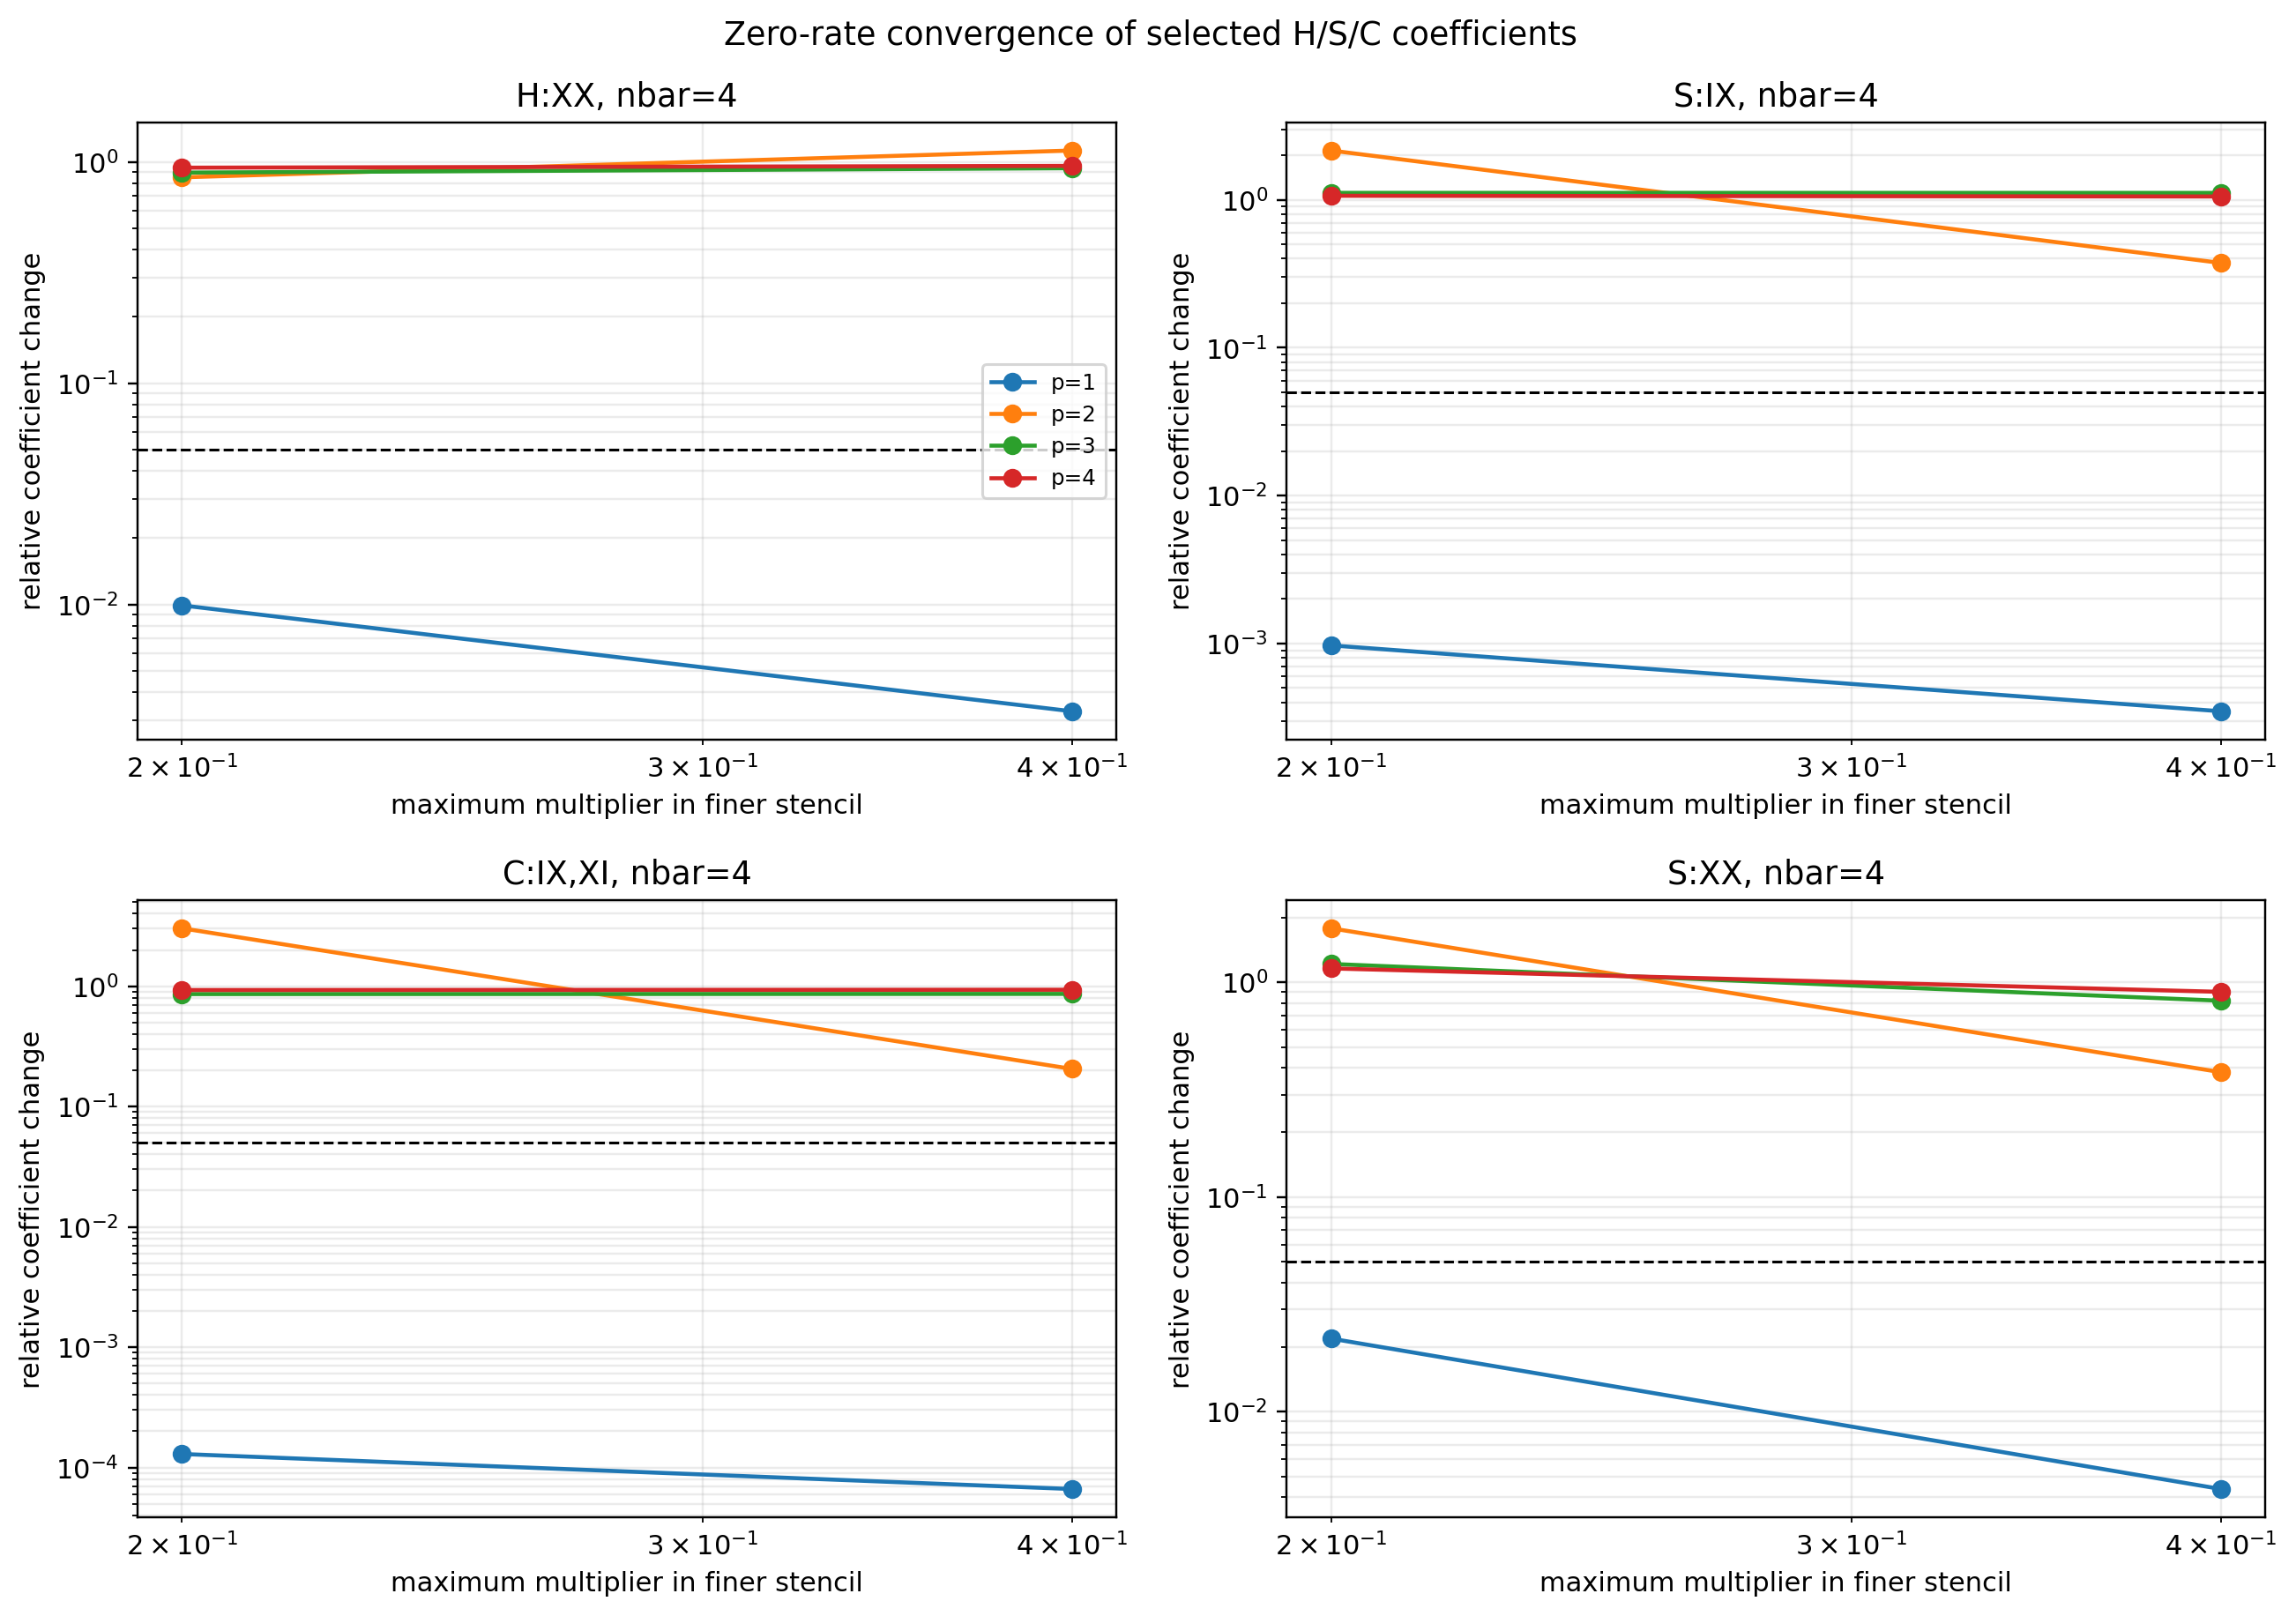

In [12]:
taxonomy_convergence = taylor_result['taxonomy_convergence']
key_component_convergence = pd.concat([
    taxonomy_convergence[
        taxonomy_convergence['sector'].eq(sector)
        & taxonomy_convergence['mode'].eq(mode)
    ]
    for sector, mode in KEY_MODES
])
key_component_convergence = key_component_convergence.sort_values(
    ['sector', 'mode', 'nbar', 'rate_power', 'fine_step_size']
)
display(key_component_convergence)
display(Image(filename=str(taylor_result['taxonomy_figure'])))

### 4.5 主張の条件

Dyson–Fréchet Taylor係数として主張するには、少なくとも次を同時に満たす必要がある。

1. $h\to0$ でfull generatorの各 $K^{(p)}$ が設定した許容誤差内に収束する。
2. 観測収束次数が正で、可能な範囲で $(4,3,2,1)$ に近づく。
3. 最細ステンシルの係数が、フィットに使っていないrate点を予測する。
4. QPTの時間分割、motional Hilbert空間打切り、CPTP射影許容誤差を変えても係数が不変である。

1–3はこの節で評価する。4は数値solverの別途収束試験であり、厳密な主張の前に必要になる。